# Assignment 1 - Data and Probability Foundations

## Group Members 

1. Bibek Chaudhary
2. Thomas Psotka
3. Sneha Koirala
4. Samo Susa

## Table of Contents


### Part 1 - Digital Services

#### a. Identify the observational unit, the relevant population, and each variable as categorical or quantitative. Create a frequency table for alert_type containing counts and percentages.


Observational unit:
The observational unit is a single latency measurement recorded for one request handled by one of the three digital services, identified by observational_id.

Relevant Population:
The relevant population is all requests handled by these three digital services over time.

Variable Classification:

1. observation_id: None,
    it is just a row label, not something we can summarize statistically.

2. service: Caterorical
    Because it is a label identifying which of the three services handled the request(e.g: orders). We compare counts/groups, not average.

3. latency_ms: Quantitative
    Because it's a numeric measurement in milliseconds: mean, median, standard deviation, and quartiles are allmeaningful for it.

4. alert_type: Categorical
    Because its a label describing the type of security alerts raised. Again summarised with counts, not average. 

In [2]:
import pandas as pd
from pathlib import Path
 
DATA = Path("../../DATA")
df_ds = pd.read_csv(DATA / "assignment01_digital_services.csv") 

counts = df_ds["alert_type"].value_counts()
percentages = (counts / counts.sum() * 100 ).round(2)

freq_table  = pd.DataFrame({"Count": counts, "Percentage": percentages})

freq_table

,Count,Percentage
alert_type,,
none,104,72.22
authentication,25,17.36
rate_limit,9,6.25
injection_signature,6,4.17


Interpretation: Most requests (72.22%) generated no alert. Authentication was the most common alert type (17.36%), followed by rate-limit alerts (6.25%) and injection-signature alerts (4.17%).This means alerts are relatively rare overall in thiis sample, with most traffic recorded as normal.

#### b. For latency_ms, report the sample size, mean, median, sample standard deviation, minimum, Q1,Q3, maximum, and IQR:
     for all observations combined; and
     separately for each service.

##### For all observations:

In [3]:
import pandas as pd
from pathlib import Path

x = df_ds["latency_ms"]

observations_combined = pd.Series({
    "n": x.size,
    "mean": x.mean(),
    "median": x.median(),
    "std_sample": x.std(ddof=1),
    "min": x.min(),
    "q1": x.quantile(0.25),
    "q3": x.quantile(0.75),
    "max": x.max(),
})

observations_combined["iqr"] = observations_combined["q3"] - observations_combined["q1"]

observations_combined 

n             144.000000
mean          110.111181
median        106.930000
std_sample     23.099319
min            75.210000
q1             95.845000
q3            116.885000
max           223.800000
iqr            21.040000
dtype: float64

Interpretation: Across all 144 observations combined, typical latency is around 106 -110 ms, with a sample standard deviation  of 23.09 ms and a IQR of 21.04 ms. The mean is somewhat higher than the median , and the maximum value is far above the Q3, which hints at a right-skewed distribution with some unusally high latency values.

##### Separetely for each service

In [4]:
def iqr(s):
    return s.quantile(0.75) - s.quantile(0.25)

by_service = (df_ds.groupby("service")["latency_ms"].agg(
                n = "size",
                mean = "mean",
                median = "median",
                std_sample = "std",
                min = "min",
                q1 = lambda x: x.quantile(0.25),
                q3 = lambda x: x.quantile(0.75),
                max = "max",
                iqr = iqr
            )
)
by_service

,n,mean,median,std_sample,min,q1,q3,max,iqr
service,,,,,,,,,
identity,49,96.067755,93.720,16.120889,75.21,85.3900,105.1000,154.27,19.71
orders,50,122.200000,114.525,24.812508,98.53,109.8375,124.1475,223.80,14.31
telemetry,45,111.970889,106.920,19.384678,86.78,97.9500,116.8300,177.87,18.88


Intrepretation: identity is the fastest and most consistent service, with the lowest typical latency and smallest spread. orders has the highest typical latency and largest standard deviation, but its IQR is actually the smallest — meaning most orders requests are tightly clustered, with a few extreme high values pulling the mean and standard deviation upward. telemetry falls in between. Across all three services, the mean exceeds the median, and each maximum sits well above Q3, hinting at right-skewed distributions with some unusually high latency values — a pattern worth flagging rather than overlooking.

#### c. Create a histogram of all latency measurements and side-by-side boxplots for the three services. Explain the histogram's axes, bins, and displayed shape and the boxplot's median, box, whiskers, and plotted potential outliers.

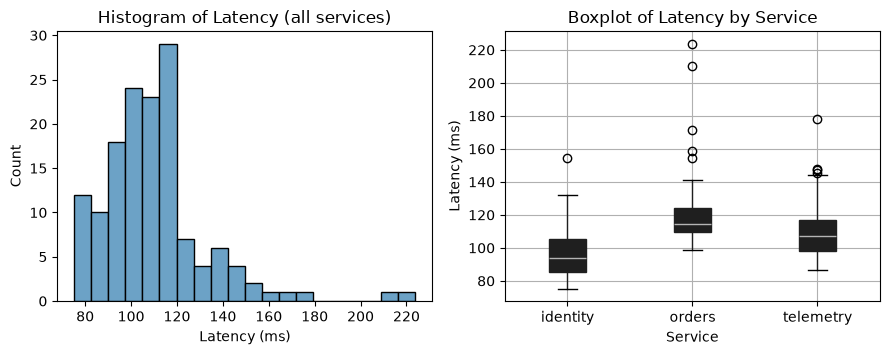

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA = Path("../../DATA")
df_ds = pd.read_csv(DATA / "assignment01_digital_services.csv")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

# Histogram
axes[0].hist(df_ds["latency_ms"], bins=20, edgecolor="black", color="#6CA2C6")
axes[0].set_xlabel("Latency (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of Latency (all services)")

# Side by side boxplots
df_ds.boxplot(column="latency_ms", by="service", ax=axes[1], patch_artist=True)
axes[1].set_title("Boxplot of Latency by Service")
axes[1].set_xlabel("Service")
axes[1].set_ylabel("Latency (ms)")

plt.suptitle("")
plt.tight_layout()
plt.show()

The histogram groups the 144 combined latency measurements into 20 equal-width bins along the horizontal axis (latency in ms), with the vertical axis showing the count of observations in each bin. The distribution is unimodal, with a main peak around 105–115 ms, and shows clear right skew: most values cluster between 75 and 120 ms, followed by a thinning tail extending past 150 ms, a visible gap around 180–205 ms, and two isolated high values near 210–220 ms.


The boxplots, read from the centre outward, show the median line inside each box, the box spanning Q1 to Q3 (the middle 50% of each service's data), and whiskers extending only to the most extreme observed values still inside the 1.5×IQR fences — not to the true minimum or maximum. Points beyond the whiskers are plotted individually as potential outliers: orders shows the most and most extreme outliers, including the sample's overall maximum near 224 ms, while identity shows only one mild outlier and telemetry shows a small cluster just above its upper whisker.

#### d. Apply the  1.5 * IQR rule within each service. Report the IDs and values of potential outliers, retain them in the analysis, and explain why a plotted outlier is not automatically a data error.

In [8]:
def flag_outliers(group):
    q1 = group["latency_ms"].quantile(0.25)
    q3 = group["latency_ms"].quantile(0.75)
    iqr_val = q3 - q1
    low = q1 - 1.5 * iqr_val
    high = q3 + 1.5 * iqr_val
    mask = (group["latency_ms"] < low) | (group["latency_ms"] > high)

    result = group.loc[mask, ["observation_id", "latency_ms"]].copy()
    result.insert(1, "service", group.name)
    return result

outliers = df_ds.groupby("service", group_keys=False).apply(flag_outliers)
outliers

,observation_id,service,latency_ms
131,132,identity,154.27
18,19,orders,210.10
59,60,orders,171.59
65,66,orders,158.59
86,87,orders,154.32
87,88,orders,223.80
32,33,telemetry,147.26
38,39,telemetry,145.52
119,120,telemetry,147.79
132,133,telemetry,177.87


Applying the 1.5×IQR rule separately within each service's own Q1 and Q3 identifies ten potential outliers out of 144 observations, all on the high-latency side.  orders has the most flagged points and the single most extreme value (223.80 ms), consistent with its largest standard deviation despite having the smallest IQR among the three services. These observations are retained in the analysis rather than removed, since the 1.5×IQR rule only flags a point relative to the shape of the observed sample and does not by itself diagnose the cause, the correct response is to flag, investigate, and explain rather than to delete. A flagged latency value could just as easily reflect a genuine slow request, caused for example by network congestion, a cold start, or momentary system load, as it could reflect a sensor or logging fault, and without further investigation into the specific conditions surrounding each request there is no basis for treating these points as errors.

#### e. Write a short descriptive comparison of the services. Comment on typical latency, spread, skewness, the relationship between mean and median, and what cannot be generalised from these descriptive differences alone.

Out of the three services, identity shows the lowest typical latency (mean 96.07 ms, median 93.72 ms) and the smallest standard deviation (16.12 ms), making it the fastest and most consistent. orders shows the highest typical latency (mean 122.20 ms, median 114.53 ms) and the largest standard deviation (24.81 ms), yet its IQR (14.31 ms) is the smallest of the three — indicating that the middle 50% of orders requests are actually tightly clustered, with a handful of extreme high values (up to 223.80 ms) inflating the mean and standard deviation. telemetry sits between the other two on both centre and spread.

In all three services, the mean exceeds the median, and each maximum sits well above its Q3, both of which point to right-skewed latency distributions — a long tail toward higher values rather than a symmetric spread — driven by a small number of unusually slow requests. This is consistent with the shape seen in the combined histogram, and with the 1.5×IQR rule flagging one outlier for identity, five for orders, and four for telemetry, all on the high-latency side.

These are purely descriptive differences observed in this particular sample of 144 requests. They do not establish that one service is inherently faster or more reliable than another as a general property of the underlying process, and they do not imply a statistically significant difference between services — that kind of claim would require a formal inferential comparison, which is outside the scope of this descriptive analysis assignment01_di...rvices.csv. The differences also say nothing about why the services differ (e.g., architecture, load, or downstream dependencies), and the presence of outliers does not by itself indicate a data quality issue, since a flagged point requires investigation rather than automatic removal or interpretation as an error.

## Part 2 - Smart-building measurements

#### a. Identify the observational unit and variables. For indoor_temp_c and energy_kwh, report n, mean, median, and sample standard deviation separately for each zone.

The observational unit is one hourly measurement taken in one zone of the building, identified by measurement_id. Each row represents one hour's worth of readings for either the north or south zone.

###### Variables:

| Variable | Type | Justification |
|---|---|---|
| `measurement_id` | Identifier | A row label, so it is not summarised statistically. |
| `hour` | Quantitative (discrete) | Numbers the hourly sequence within the two-day window. It is used for ordering and plotting, rather than usually being averaged. |
| `zone` | Categorical | A label, `north` or `south`, compared by grouping rather than averaging. |
| `outdoor_temp_c` | Quantitative (continuous) | A numeric temperature measurement in degrees Celsius. |
| `indoor_temp_c` | Quantitative (continuous) | A numeric temperature measurement in degrees Celsius; its mean, median, standard deviation, and quartiles are meaningful. |
| `energy_kwh` | Quantitative (continuous) | A numeric energy measurement in kilowatt-hours; its mean, median, standard deviation, and quartiles are meaningful. |

In [2]:
import pandas as pd
from pathlib import Path

# Load the smart-building data
DATA = Path("../../DATA")
df_sb = pd.read_csv(DATA / "assignment01_smart_building.csv")

# Reusable function so we don't repeat code for each variable
def zone_summary(df, col):
    return (
        df.groupby("zone")[col]
        .agg(
            n="size",
            mean="mean",
            median="median",
            std_sample="std",
        )
    )

indoor_temp_summary = zone_summary(df_sb, "indoor_temp_c")
energy_summary = zone_summary(df_sb, "energy_kwh")

print("Indoor temperature (°C) by zone:")
display(indoor_temp_summary)

print("Energy (kWh) by zone:")
display(energy_summary)

Indoor temperature (°C) by zone:


,n,mean,median,std_sample
zone,,,,
north,48,21.276458,21.240,0.614563
south,48,22.267083,22.285,0.548208


Energy (kWh) by zone:


,n,mean,median,std_sample
zone,,,,
north,48,39.446458,39.84,3.975399
south,48,37.331042,37.08,4.151442


Intrepretation: Both zones have 48 hourly observations, consistent with two full days of monitoring. For indoor temperature, south is on average about 1°C warmer than north (mean 22.27°C vs. 21.28°C, median 22.29°C vs. 21.24°C), and both zones show low variability (sample SD of 0.55–0.61°C), indicating that indoor temperature is kept fairly stable within each zone across the two days. For energy consumption, north uses slightly more energy on average than south (mean 39.45 kWh vs. 37.33 kWh), and both zones show noticeably more variability in energy use (sample SD ≈ 4 kWh) than in indoor temperature. In both variables and both zones, the mean and median are close to one another, suggesting roughly symmetric distributions without strong skew.

#### b. Plot indoor temperature against hour, using a separate line for each zone. Describe the time pattern and explain what each axis and line represent.

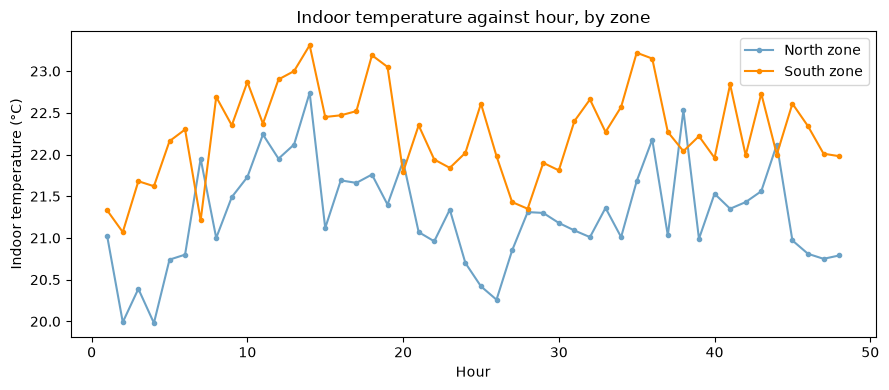

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))

for zone, color in [("north", "#6CA2C6"), ("south", "#FF8C00")]:
    part = df_sb[df_sb["zone"] == zone].sort_values("hour")
    ax.plot(
        part["hour"],
        part["indoor_temp_c"],
        marker=".",
        color=color,
        label=f"{zone.capitalize()} zone",
    )

ax.set_xlabel("Hour")
ax.set_ylabel("Indoor temperature (°C)")
ax.set_title("Indoor temperature against hour, by zone")
ax.legend()
plt.tight_layout()
plt.show()

The horizontal axis shows hour, the sequential hour across the two-day monitoring period, and the vertical axis shows indoor_temp_c in degrees Celsius. The blue line traces the north zone's indoor temperature over time, and the orange line traces the south zone's.


Both zones show a repeating daily cycle across the 48-hour window, completing two full up-and-down cycles that correspond to the two monitored days: temperature dips to its lowest point in the early morning hours and rises to a peak in the afternoon, before falling again into the evening. Throughout almost the entire period, the south zone's line sits above the north zone's line, consistent with south's higher mean and median found earlier. The south line also shows sharper hour-to-hour swings than the more gradual north line. Both lines tend to rise and fall at similar points in time, suggesting the two zones respond to a shared daily driver — most plausibly the outdoor temperature cycle — rather than fluctuating independently.

#### c. Create a scatterplot of outdoor_temp_c against energy_kwh, using colour or separate panels for the zones. Describe the direction, form, strength, and unusual points visible in the association.

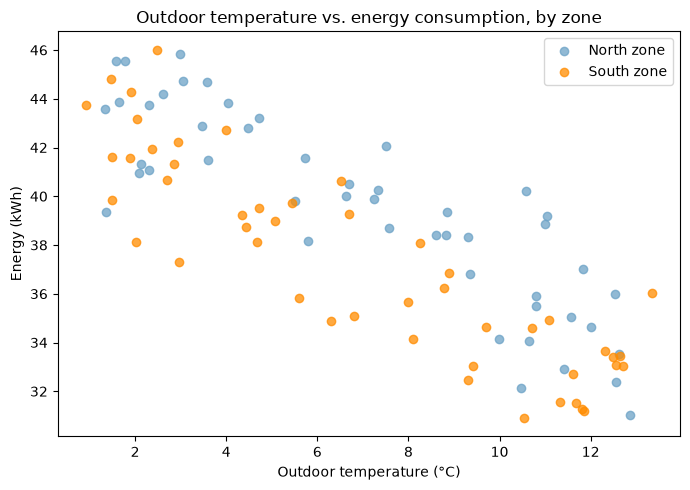

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for zone, color in [("north", "#6CA2C6"), ("south", "#FF8C00")]:
    part = df_sb[df_sb["zone"] == zone]
    ax.scatter(
        part["outdoor_temp_c"],
        part["energy_kwh"],
        color=color,
        label=f"{zone.capitalize()} zone",
        alpha=0.75,
    )

ax.set_xlabel("Outdoor temperature (°C)")
ax.set_ylabel("Energy (kWh)")
ax.set_title("Outdoor temperature vs. energy consumption, by zone")
ax.legend()
plt.tight_layout()
plt.show()

Direction — negative


As outdoor_temp_c increases, energy_kwh decreases, and this holds for both zones.
At low outdoor temperatures (around 1–3°C), energy consumption clusters near 42–46 kWh.
At high outdoor temperatures (around 12–13°C), energy consumption drops to roughly 31–35 kWh.
This pattern is consistent with what would be expected if heating demand rises in colder conditions, though this description alone does not establish causation.


Form — roughly linear


The downward pattern looks like a fairly straight-line decline rather than a curve, plateau, or U-shape.
Points fall in a consistent downward band from the upper-left (cold, high energy) to the lower-right (warm, low energy).
There is no visible bend or reversal in direction across the observed temperature range.


Strength — moderate


The relationship is visible and consistent, but not tight or perfect.
Points are scattered in a fairly wide band around the general downward trend rather than sitting close to a single line.
Example: near outdoor temperature ≈8°C, energy values range from about 34 kWh up to nearly 40 kWh — a spread of roughly 6 kWh at essentially the same temperature.
This scatter indicates outdoor temperature is an important influence on energy use, but other factors also contribute to the variation.


Unusual points


A north point near outdoor temp ≈10.5°C sits at about 40.2 kWh — noticeably higher than the surrounding cluster of points at similar temperatures (which sit around 32–36 kWh).
A south point near outdoor temp ≈13.3°C sits at about 36 kWh — higher than expected given how low other points are at similarly high temperatures (mostly 31–33 kWh nearby).
A couple of points around outdoor temp ≈11–12°C dip unusually low, closer to 31 kWh, below the general band of the surrounding cloud.
These points don't disrupt the overall pattern, but they are worth naming as visible departures from the general negative trend.


Zone comparison


The north (blue) and south (orange) points are heavily intermixed across the whole plot.
Neither zone's cloud sits consistently above or below the other's.
This suggests the outdoor-temperature–energy relationship behaves similarly in both zones, rather than one zone being systematically more or less energy-efficient than the other

#### d. Write a short conclusion about temperature stability, differences between zones, and the visible energy–temperature relationship. Do not calculate correlation, fit a regression model, or make causal claims at this stage.

Temperature stability


Indoor temperature is fairly stable within each zone across the two-day monitoring window. Both north (sample SD 0.61°C) and south (sample SD 0.55°C) show relatively small hour-to-hour variation, and the run plot shows a smooth, repeating daily cycle rather than erratic jumps — temperature dips in the early morning hours and rises to a peak in the afternoon, in a consistent wave-like pattern across both days.


Differences between zones


The two zones differ consistently on both variables. For indoor temperature, south runs about 1°C warmer than north on both mean and median (south: mean 22.27°C, median 22.29°C; north: mean 21.28°C, median 21.24°C), and this gap holds steadily across the full two-day period rather than appearing only at certain hours. Energy consumption shows the opposite ranking: north averages slightly higher energy use than south (39.45 kWh vs. 37.33 kWh), though with somewhat more spread in energy than in indoor temperature for both zones.


Visible energy–temperature relationship
The scatterplot of outdoor temperature against energy consumption shows a clear negative, roughly linear, moderate-strength association in both zones: lower outdoor temperatures are associated with higher energy consumption, and higher outdoor temperatures with lower energy consumption, with the two zones' points closely intermixed rather than forming separate patterns. A few points depart from this general trend, showing higher- or lower-than-expected energy use at a given outdoor temperature, but the overall downward pattern is consistent across the two-day sample. These findings describe only the pattern observed in this specific 48-hour, two-zone sample — no correlation coefficient, regression line, or causal mechanism has been estimated, and the descriptive pattern alone does not establish that outdoor temperature causes the observed change in energy use, nor that the two zones would behave the same way under different conditions or over a longer period.